## Desafio 4 da Trilha de Visão Computacional — Estimativa de Pose

> **Resumo:** Usamos a **YOLO-pose** para estimar a **pose** de pessoas numa imagem: o modelo
> detecta cada pessoa e marca 17 pontos do corpo (*keypoints*) — ombros, cotovelos, joelhos, etc.
> — desenhando o "esqueleto". É a base de análise esportiva, fisioterapia, captura de movimento.

> 📝 **O que é pose estimation?** Em vez de só uma caixa ao redor da pessoa, a rede localiza as
> **articulações** e como elas se conectam. Com isso dá pra medir ângulos, contar repetições de um
> exercício, detectar quedas, etc.

Nesse desafio você irá implementar uma solução simples para reconhecimento de poses, muito útil em análises esportivas por exemplo.

Para isso você deverá seguir os pasos desse documento atentamente.

### Instalação e Importação da Biblioteca

In [1]:
!pip install ultralytics matplotlib torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00


In [2]:
import ultralytics
import matplotlib.pyplot as plt
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Processar Dados



In [3]:
# Baixa o modelo de pose da YOLO.
model = ultralytics.YOLO("yolo11n-pose.pt")

device = "cuda" if torch.cuda.is_available() else "cpu"  # GPU se disponível, senão CPU
model = model.to(device)
print(f"Rodando em: {device}")

# Processa a imagem.
# TODO testar outras imagens.
results = model("desafio_4.jpeg")  # predict on an image

Rodando em: cpu

image 1/1 /content/desafio_4.jpeg: 288x640 5 persons, 335.6ms
Speed: 3.8ms preprocess, 335.6ms inference, 47.2ms postprocess per image at shape (1, 3, 288, 640)


### Visualizar Resultados

Pessoas detectadas: 5
Formato dos keypoints: (5, 17, 3)  (pessoas, pontos, [x, y, confiança])
São 17 pontos do corpo no padrão COCO: nariz, olhos, orelhas, ombros, cotovelos, punhos, quadris, joelhos e tornozelos.


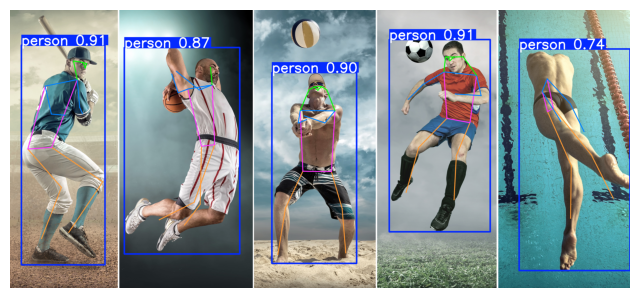

In [4]:
import cv2

# Resumo textual do resultado
r = results[0]
n_pessoas = len(r.boxes) if r.boxes is not None else 0
print(f"Pessoas detectadas: {n_pessoas}")
if r.keypoints is not None and len(r.keypoints) > 0:
    print(f"Formato dos keypoints: {tuple(r.keypoints.data.shape)}  (pessoas, pontos, [x, y, confiança])")
    print("São 17 pontos do corpo no padrão COCO: nariz, olhos, orelhas, ombros, cotovelos, punhos, quadris, joelhos e tornozelos.")

# Gera a visualização do resultado (com o esqueleto desenhado sobre a pessoa)
im_array = r.plot()
rgb_img = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)  # plot() retorna BGR; convertemos para RGB

# Visualiza a imagem rgb_img
plt.figure(figsize=(8, 8))
plt.imshow(rgb_img)
plt.axis("off")
plt.show()

### Referência

- https://docs.ultralytics.com/tasks/pose